## Testing docker images

Done:
* troubleshot docker images
* get_value
* set_value (channel storage)

now:
* set_value (discharge)
* set_value (others?)


<!-- * bmi-plugin implementation
 bmi-model implementation
current date: 2026-02-13

- [x] Troubleshot Docker images
- [x] get_value

- [x] text -->



In [1]:
# docker build -t ewatercycle-pcr-17feb .
# docker save -o ewatercycle_pcr_17feb.tar ewatercycle-pcr-17feb
# apptainer build ewatercycle_pcr_17feb.sif docker-archive://ewatercycle_pcr_17feb.tar

In [2]:
import sys
from pathlib import Path

import ewatercycle.forcing
import ewatercycle.models
import ewatercycle.observation.grdc
import ewatercycle.parameter_sets
from ewatercycle.container import ContainerImage
from rich import print

PROJECT_ROOT = Path().resolve().parents[2]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cartopy import crs
from cartopy import feature as cfeature
from matplotlib.colors import LogNorm
from tqdm.notebook import tqdm

from src.aral import load_grdc_monthly
from src.constants import STATIONS_PCR
from src.paths import FORCING_PCRGLOB, GRDC, INI_FILES, LOAD_PCR, PCR_GLOBAL_PARAMS, PCR_TAIL

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


In [3]:
STATIONS_PCR

{'Chatly': {'lat': 42.2, 'lon': 60.2},
 'Kazalinsk': {'lat': 45.7, 'lon': 62.12},
 'Kerki': {'lat': 37.83, 'lon': 65.25},
 'Tyumen-Aryk': {'lat': 43.95, 'lon': 67.05},
 'Karaozek': {'lat': 44.95, 'lon': 65.27}}

In [4]:
pcr_glob_directory = PCR_GLOBAL_PARAMS  # GlobalOption uit .ini
prepared_pcr_forcing = FORCING_PCRGLOB / LOAD_PCR / PCR_TAIL


parameter_set_test = ewatercycle.parameter_sets.ParameterSet(
    name="custom_parameter_set",
    directory=pcr_glob_directory,
    config=INI_FILES / "test_container_images.ini",
    target_model="pcrglobwb",
    supported_model_versions={"17feb"},
)

forcing = ewatercycle.forcing.sources["PCRGlobWBForcing"].load(
    directory=prepared_pcr_forcing,
)

In [5]:
my_image = ContainerImage("/home/avandervee3/ewatercycle_pcr_17feb.sif")
my_image.version

'17feb'

In [6]:
reference = ewatercycle.models.PCRGlobWB(
    parameter_set=parameter_set_test, forcing=forcing, bmi_image=my_image
)


print(reference)

PCRGlobWB(
    parameter_set=ParameterSet(
        name='custom_parameter_set',
        directory=PosixPath('/data/shared/parameter-sets/pcrglobwb_global'),
        config=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_i
n_progress/model_runs/pcrglobwb/ini_files/test_container_images.ini'),
        doi='N/A',
        target_model='pcrglobwb',
        supported_model_versions={'17feb'},
        downloader=None
    ),
    forcing=PCRGlobWBForcing(
        start_time='1940-01-01T00:00:00Z',
        end_time='1960-12-31T00:00:00Z',
        directory=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/wor
k_in_progress/forcing/output/PCRGLOBWB/ERA5_1940-1960/AralSea_basin/work/diagnostic/script'),
        shape=PosixPath('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in
_progress/forcing/output/PCRGLOBWB/ERA5_1940-1960/AralSea_basin/work/diagnostic/script/AralSea_basin.shp'),
        filenames={},
        precipitationNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_pr_1940-1960_AralSea_basin.nc',
        temperatureNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_tas_1940-1960_AralSea_basin.nc'
    )
)

In [7]:
experiment_start_date = "1950-01-01T00:00:00Z"
experiment_end_date = "1950-01-10T00:00:00Z"

In [8]:
reference_config, reference_dir = reference.setup(
    start_time=experiment_start_date, end_time=experiment_end_date, max_spinups_in_years=0
)
reference_config, reference_dir

('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/exploration/Image_tests/pcrglobwb_20260218_124727/pcrglobwb_ewatercycle.ini',
 '/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/exploration/Image_tests/pcrglobwb_20260218_124727')

In [9]:
print(reference.parameters)

refence_para = reference.parameters

# Convert ISO 8601 strings to datetime objects
start_time = datetime.strptime(experiment_start_date, "%Y-%m-%dT%H:%M:%SZ")
end_time = datetime.strptime(experiment_end_date, "%Y-%m-%dT%H:%M:%SZ")

# Calculate the number of days for the progression bar
delta = end_time - start_time
number_of_days = delta.days
print(f"Number of days to model: {number_of_days}")

dict_items([('start_time', '1950-01-01T00:00:00Z'), ('end_time', '1950-01-10T00:00:00Z'), ('routing_method', 
'accuTravelTime'), ('max_spinups_in_years', '0')])

Number of days to model: 9

In [10]:
# print("Using config:", reference_config)

In [11]:
reference.initialize(reference_config)

In [12]:
time = pd.date_range(reference.start_time_as_isostr, reference.end_time_as_isostr)
stations_timeseries = pd.DataFrame(
    index=pd.Index(time, name="time"), columns=["Chatly", "Kerki", "Tyumen", "Kazalinsk"]
)
stations_timeseries.head()


stations_timeseries_getvalue = stations_timeseries.copy()
stations_timeseries_setvalue = stations_timeseries.copy()
stations_timeseries_setvalue_before = stations_timeseries.copy()
stations_timeseries_reference = stations_timeseries.copy()


channel_storage_getvalue_series = stations_timeseries.copy()
channel_storage_setvalue_before_update_series = stations_timeseries.copy()
channel_storage_setvalue_series = stations_timeseries.copy()

In [13]:
for _ in tqdm(range(number_of_days), desc="Running model"):
    reference.update()

print("Model run finished!")

Running model:   0%|          | 0/9 [00:00<?, ?it/s]

Model run finished!

In [14]:
soil_moisture = reference.get_value_as_xarray("discharge")

# Copy the field and manually overwrite a random part of the domain
irrigated_soil_moisture = soil_moisture.copy()
# irrigated_soil_moisture[100:200, 100:200] += 100

# Indices of the point
lat_idx = 61
lon_idx = 127

# Add 100 to that specific cell
irrigated_soil_moisture.values[lat_idx, lon_idx] += 10000000
print(irrigated_soil_moisture.values[lat_idx, lon_idx])

10003698.547363281

In [15]:
# Find the maximum value
max_value = soil_moisture.max().values

# Step 1: find the longitude index where max occurs along longitude for each latitude
lon_of_max = soil_moisture.idxmax(dim="longitude")

# Step 2: find the latitude where the global maximum occurs
lat_of_max = lon_of_max.idxmax(dim="latitude")

# Get the corresponding longitude
lon_max = lon_of_max.sel(latitude=lat_of_max)

print("Maximum value:", max_value)
print("Location (longitude, latitude):", (lon_max.values, lat_of_max.values))

Maximum value: 186644.78125

Location (longitude, latitude):
(array(51.79166667), array(54.875))

In [16]:
lat = 63.5
lon = 39.1
value = irrigated_soil_moisture.sel(longitude=lon, latitude=lat, method="nearest")
print(value)

<xarray.DataArray ()> Size: 8B
array(0.18982384)
Coordinates:
    latitude   float64 8B 63.54
    longitude  float64 8B 39.13

In [17]:
print(np.shape(soil_moisture))

(216, 324)

In [18]:
soil_moisture

<xarray.DataArray (longitude: 216, latitude: 324)> Size: 560kB
array([[2.80092587e-03, 7.33333407e-04, 1.38082250e-03, ...,
        2.52314820e-03, 7.23379618e-03, 5.96064795e-03],
       [1.15740741e-05, 1.47639820e-02, 6.11111103e-03, ...,
        3.63773137e-01, 0.00000000e+00, 3.58796306e-03],
       [9.83796315e-04, 1.17929369e-01, 7.80125335e-02, ...,
        2.29826391e-01, 0.00000000e+00, 2.80787032e-02],
       ...,
       [4.48495373e-02, 3.34143527e-02, 1.21846899e-01, ...,
        8.05535167e-03, 2.35702264e-05, 0.00000000e+00],
       [6.13425917e-04, 3.00925924e-04, 6.10185191e-02, ...,
        2.68518529e-03, 0.00000000e+00, 0.00000000e+00],
       [2.39120368e-02, 2.83564813e-03, 1.17361108e-02, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])
Coordinates:
  * latitude   (latitude) float64 3kB 53.04 53.12 53.21 ... 79.79 79.87 79.96
  * longitude  (longitude) float64 2kB 34.04 34.13 34.21 ... 51.79 51.88 51.96

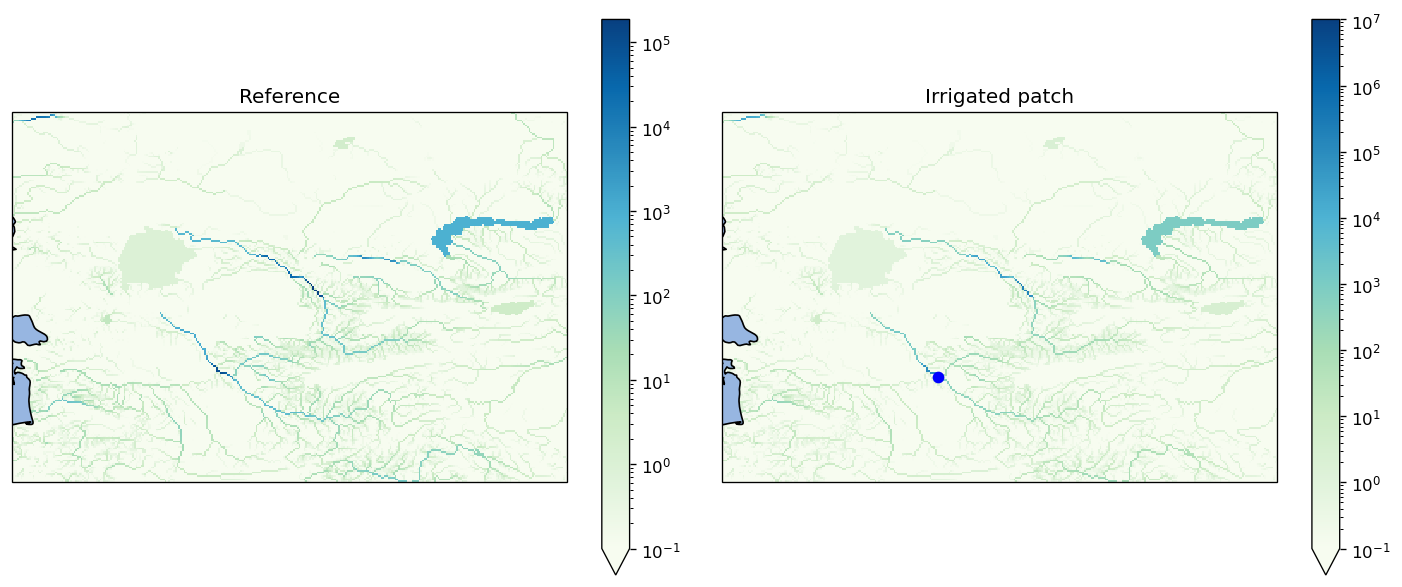

In [19]:
fig = plt.figure(figsize=(12, 5), dpi=120)
left_axes = fig.add_subplot(121, projection=crs.PlateCarree())
right_axes = fig.add_subplot(122, projection=crs.PlateCarree())

# Replace non-positive values with a small number
soil_moisture_safe = soil_moisture.where(soil_moisture > 0, 1e-6)
irrigated_soil_moisture_safe = irrigated_soil_moisture.where(irrigated_soil_moisture > 0, 1e-6)

soil_moisture_safe.plot.imshow(
    ax=left_axes,
    cmap="GnBu",
    norm=LogNorm(vmin=0.1, vmax=soil_moisture_safe.max()),
    x="latitude",
    y="longitude",
    extent=[63, 64, 39, 40],
)

irrigated_soil_moisture_safe.plot.imshow(
    ax=right_axes,
    cmap="GnBu",
    norm=LogNorm(vmin=0.1, vmax=irrigated_soil_moisture_safe.max()),
    x="latitude",
    y="longitude",
    extent=[63, 64, 39, 40],
)
# Decoration
left_axes.set_title("Reference")
right_axes.set_title("Irrigated patch")

for axes in [left_axes, right_axes]:
    axes.add_feature(cfeature.OCEAN, zorder=2)
    # axes.add_feature(cfeature.RIVERS, zorder=2, color="k")
    axes.coastlines(zorder=3)

plt.plot(
    [63.5],
    [39.1],
    color="blue",
    linewidth=2,
    marker="o",
)

# 39.12201764473881, 63.588272078851375
plt.tight_layout()

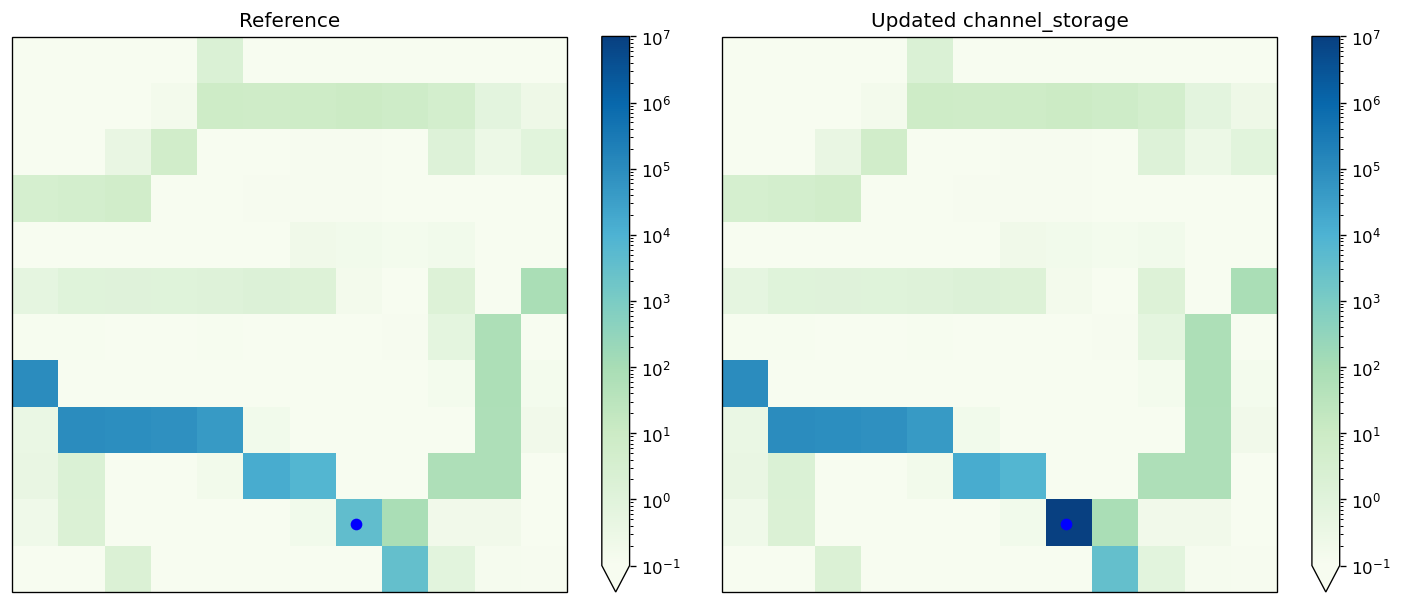

In [20]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# -----------------------------
# Replace non-positive values
# -----------------------------
soil_moisture_safe = soil_moisture.where(soil_moisture > 0, 1e-6)
irrigated_soil_moisture_safe = irrigated_soil_moisture.where(irrigated_soil_moisture > 0, 1e-6)

# Swap coordinates names
soil_moisture_safe = soil_moisture_safe.rename({"latitude": "longitude", "longitude": "latitude"})

irrigated_soil_moisture_safe = irrigated_soil_moisture_safe.rename(
    {"latitude": "longitude", "longitude": "latitude"}
)


# -----------------------------
# Define zoom box (lon/lat)
# -----------------------------
lon_min, lon_max = 63, 64
lat_min, lat_max = 39, 40

# Ensure correct slicing even if coordinates are descending
lat0, lat1 = sorted([lat_min, lat_max])
lon0, lon1 = sorted([lon_min, lon_max])

soil_moisture_subset = soil_moisture_safe.sel(
    longitude=slice(lon0, lon1), latitude=slice(lat0, lat1)
)

irrigated_soil_moisture_subset = irrigated_soil_moisture_safe.sel(
    longitude=slice(lon0, lon1), latitude=slice(lat0, lat1)
)

# -----------------------------
# Set up figure
# -----------------------------
fig = plt.figure(figsize=(12, 5), dpi=120)
left_axes = fig.add_subplot(121, projection=ccrs.PlateCarree())
right_axes = fig.add_subplot(122, projection=ccrs.PlateCarree())

# -----------------------------
# Plot the subsets
# -----------------------------
soil_moisture_subset.plot(
    ax=left_axes,
    x="longitude",
    y="latitude",
    cmap="GnBu",
    norm=LogNorm(vmin=0.1, vmax=irrigated_soil_moisture_safe.max()),
)

irrigated_soil_moisture_subset.plot(
    ax=right_axes,
    x="longitude",
    y="latitude",
    cmap="GnBu",
    norm=LogNorm(vmin=0.1, vmax=irrigated_soil_moisture_safe.max()),
)

# -----------------------------
# Decorations
# -----------------------------
left_axes.set_title("Reference")
right_axes.set_title("Updated channel_storage")

for ax in [left_axes, right_axes]:
    ax.add_feature(cfeature.OCEAN, zorder=2)
    ax.coastlines(zorder=3)

# -----------------------------
# Plot a point
# -----------------------------
point_lon, point_lat = 63.62, 39.122
for ax in [left_axes, right_axes]:
    ax.plot(
        point_lon, point_lat, color="blue", linewidth=2, marker="o", transform=ccrs.PlateCarree()
    )

plt.tight_layout()
plt.show()

In [21]:
# lon_idx = int(abs(soil_moisture_safe.longitude - point_lon).argmin().values)

# # Find the index along latitude
# lat_idx = int(abs(soil_moisture_safe.latitude - point_lat).argmin().values)

# print("Index along longitude:", lon_idx)
# print("Index along latitude:", lat_idx)

## Set_value

In [22]:
set_value_start_date = "1949-01-01T00:00:00Z"
set_value_end_date = "1950-12-31T00:00:00Z"

In [23]:
test_get_value = ewatercycle.models.PCRGlobWB(
    parameter_set=parameter_set_test, forcing=forcing, bmi_image=my_image
)


test_set_value = ewatercycle.models.PCRGlobWB(
    parameter_set=parameter_set_test, forcing=forcing, bmi_image=my_image
)

test_set_value_before_update = ewatercycle.models.PCRGlobWB(
    parameter_set=parameter_set_test, forcing=forcing, bmi_image=my_image
)

In [24]:
test_get_value_config, test_get_value_dir = test_get_value.setup(
    start_time=set_value_start_date, end_time=set_value_end_date, max_spinups_in_years=0
)
test_get_value_config, test_get_value_dir

test_set_value_config, test_set_value_dir = test_set_value.setup(
    start_time=set_value_start_date, end_time=set_value_end_date, max_spinups_in_years=0
)
test_set_value_config, test_set_value_dir

test_set_value_before_update_config, test_set_value_before_update_dir = (
    test_set_value_before_update.setup(
        start_time=set_value_start_date, end_time=set_value_end_date, max_spinups_in_years=0
    )
)
test_set_value_before_update_config, test_set_value_before_update_dir

('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/exploration/Image_tests/pcrglobwb_20260218_124944/pcrglobwb_ewatercycle.ini',
 '/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/notebooks/exploration/Image_tests/pcrglobwb_20260218_124944')

In [25]:
print(reference.parameters)

test_get_value_para = test_set_value.parameters

# Convert ISO 8601 strings to datetime objects
start_time = datetime.strptime(set_value_start_date, "%Y-%m-%dT%H:%M:%SZ")
end_time = datetime.strptime(set_value_end_date, "%Y-%m-%dT%H:%M:%SZ")

# Calculate the number of days for the progression bar
delta = end_time - start_time
number_of_days = delta.days
print(f"Number of days to model: {number_of_days}")

dict_items([('start_time', '1950-01-01T00:00:00Z'), ('end_time', '1950-01-10T00:00:00Z'), ('routing_method', 
'accuTravelTime'), ('max_spinups_in_years', '0')])

Number of days to model: 729

In [26]:
test_set_value.initialize(test_set_value_config)
test_set_value_before_update.initialize(test_set_value_before_update_config)
test_get_value.initialize(test_get_value_config)

In [27]:
lat_idx = 61
lon_idx = 127
m3s = 300
m3day = m3s * 24 * 3600

# make sure it is run once before editing values etc
test_get_value.update()
test_set_value_before_update.update()
test_set_value.update()


for _ in tqdm(range(number_of_days - 1), desc="Running model"):
    #### Update channel storage before update
    test_variable_before = test_set_value_before_update.get_value_as_xarray(
        "channel_storage",
    )
    test_values_before = test_variable_before.values.copy()
    test_values_before[lat_idx, lon_idx] -= m3day
    test_set_value_before_update.set_value("channel_storage", test_values_before.flatten())

    #### Timestep
    test_get_value.update()
    test_set_value_before_update.update()
    test_set_value.update()

    #### Update channel storage after update
    test_variable = test_set_value.get_value_as_xarray(
        "channel_storage",
    )
    test_values = test_variable.values.copy()
    test_values[lat_idx, lon_idx] -= m3day
    test_set_value.set_value("channel_storage", test_values.flatten())

    #### Track discharge at station locations
    time = test_set_value.time_as_isostr

    for station_name, coords in STATIONS_PCR.items():
        discharge_getvalue = test_get_value.get_value_at_coords(
            "discharge",
            lat=[coords["lat"]],
            lon=[coords["lon"]],
        )

        channel_storage_getvalue = test_get_value.get_value_at_coords(
            "channel_storage",
            lat=[coords["lat"]],
            lon=[coords["lon"]],
        )

        discharge_setvalue = test_set_value.get_value_at_coords(
            "discharge",
            lat=[coords["lat"]],
            lon=[coords["lon"]],
        )

        channel_storage_setvalue = test_set_value.get_value_at_coords(
            "channel_storage",
            lat=[coords["lat"]],
            lon=[coords["lon"]],
        )

        discharge_setvalue_before = test_set_value_before_update.get_value_at_coords(
            "discharge",
            lat=[coords["lat"]],
            lon=[coords["lon"]],
        )

        channel_storage_setvalue_before_update = test_set_value_before_update.get_value_at_coords(
            "channel_storage",
            lat=[coords["lat"]],
            lon=[coords["lon"]],
        )

        stations_timeseries_getvalue.loc[time, station_name] = discharge_getvalue[0]
        stations_timeseries_setvalue.loc[time, station_name] = discharge_setvalue[0]
        stations_timeseries_setvalue_before.loc[time, station_name] = discharge_setvalue_before[0]

        channel_storage_getvalue_series.loc[time, station_name] = channel_storage_getvalue[0]
        channel_storage_setvalue_before_update_series.loc[time, station_name] = (
            channel_storage_setvalue_before_update[0]
        )
        channel_storage_setvalue_series.loc[time, station_name] = channel_storage_setvalue[0]


print("Model run finished!")

Running model:   0%|          | 0/728 [00:00<?, ?it/s]

Model run finished!

## test get value

bmi implementation

In [28]:
# get_value_experiment_start_date = "1949-06-01T00:00:00Z"
# get_value_experiment_end_date = "1950-12-31T00:00:00Z"

In [29]:
# test_get_value = ewatercycle.models.PCRGlobWB(
#     parameter_set=parameter_set_test,
#     forcing=forcing,
#     bmi_image=my_image
# )


In [30]:
# test_get_value_config, test_get_value_dir = test_get_value.setup(
#     start_time = get_value_experiment_start_date,
#     end_time = get_value_experiment_end_date,
#     max_spinups_in_years=0
# )
# test_get_value_config, test_get_value_dir

In [31]:
# print(reference.parameters)

# test_get_value_para = test_get_value.parameters

# # Convert ISO 8601 strings to datetime objects
# start_time = datetime.strptime(get_value_experiment_start_date, '%Y-%m-%dT%H:%M:%SZ')
# end_time = datetime.strptime(get_value_experiment_end_date, '%Y-%m-%dT%H:%M:%SZ')

# # Calculate the number of days for the progression bar
# delta = end_time - start_time
# number_of_days = delta.days
# print(f"Number of days to model: {number_of_days}")

In [32]:
# test_get_value.initialize(test_get_value_config)

In [33]:
# for _ in tqdm(range(number_of_days), desc="Running model"):

#     test_get_value.update()

#     #Track discharge at station locations
#     time = test_get_value.time_as_isostr

#     for station_name, coords in STATIONS_PCR.items():

#         discharge = test_get_value.get_value_at_coords(
#             "discharge",
#             lat=[coords["lat"]],
#             lon=[coords["lon"]],
#         )

#         stations_timeseries_getvalue.loc[time, station_name] = discharge[0]

#     # test_values = test_get_value.get_value("discharge")
#     # print(f"max = {np.max(test_values)}")

# #     discharge_at_station = test_get_value.get_value_at_coords(
# #     "discharge",
# #     lat=[lat],
# #     lon=[lon]
# # )


# # print(type(test_values))
# print("Model run finished!")

# #print(type(discharge_at_Chatly))

In [34]:
grdc_station_id = "2817100"
data_home = GRDC / "Daily"

observations = ewatercycle.observation.grdc.get_grdc_data(
    station_id=grdc_station_id,
    start_time="1900-01-01T00:00:00Z",  # or: model_instance.start_time_as_isostr
    end_time="1990-12-15T00:00:00Z",
    data_home=data_home,
)
observations

<xarray.Dataset> Size: 223kB
Dimensions:              (time: 13880)
Coordinates:
  * time                 (time) datetime64[ns] 111kB 1936-01-01 ... 1973-12-31
    id                   int64 8B 2817100
Data variables:
    streamflow           (time) float64 111kB 688.0 664.0 614.0 ... 153.0 158.0
    area                 float64 8B 4.5e+05
    country              <U2 8B 'UZ'
    geo_x                float64 8B 59.7
    geo_y                float64 8B 42.28
    geo_z                float64 8B 72.0
    owneroforiginaldata  <U85 340B 'Initial dataset collected in the framewor...
    river_name           <U9 36B 'AMU DARYA'
    station_name         <U6 24B 'CHATLY'
    timezone             float64 8B nan
Attributes:
    title:          NA
    Conventions:    CF-1.7
    references:     grdc.bafg.de
    institution:    GRDC
    history:        Converted from 2817100_Q_Day.Cmd.txt of 2025-09-02 to net...
    missing_value:  -999.000

In [35]:
Syr_kaza = load_grdc_monthly(2316201, name="Syr Darya Kazalinsk")
Amu_chatly = load_grdc_monthly(2817100, name="Amu Darya Chatly")

In [36]:
# stations_timeseries_getvalue.loc["1950"][["Karaozek"]].plot(label = "get_value")
# stations_timeseries_setvalue.loc["1950"][["Karaozek"]].plot(label = "set_value")

# #stations_timeseries_getvalue.loc["1950"][["Kerki","Chatly"]].plot()


# #observations.sel(time="1950")["streamflow"].plot(label = "GRDC-Chatly")
# plt.legend()
# #stations_timeseries.plot()

<Axes: xlabel='time'>

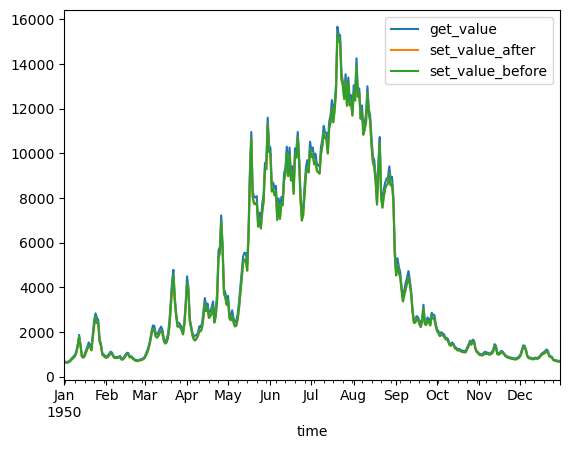

In [37]:
combined = pd.concat(
    [
        stations_timeseries_getvalue.loc["1950", ["Chatly"]].rename(
            columns={"Chatly": "get_value"}
        ),
        stations_timeseries_setvalue.loc["1950", ["Chatly"]].rename(
            columns={"Chatly": "set_value_after"}
        ),
        stations_timeseries_setvalue_before.loc["1950", ["Chatly"]].rename(
            columns={"Chatly": "set_value_before"}
        ),
    ],
    axis=1,
)

combined.plot()

<function matplotlib.pyplot.show(close=None, block=None)>

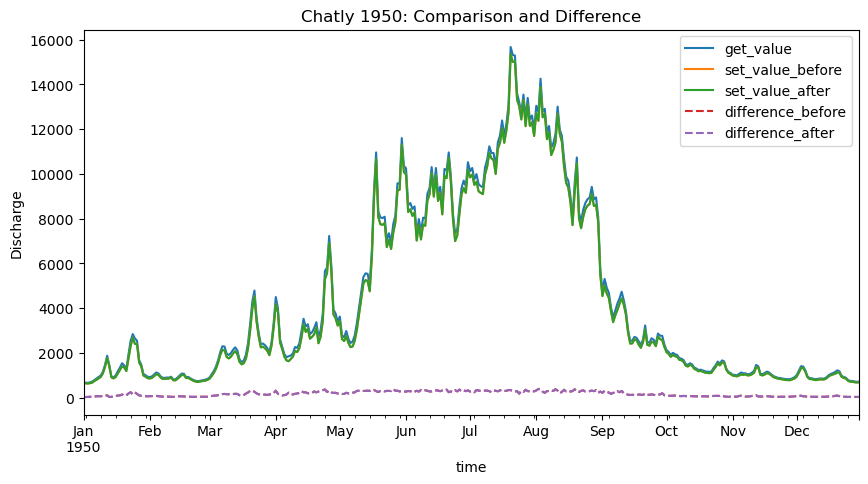

In [38]:
# Compute difference: get_value - set_value

combined["difference_before"] = combined["get_value"] - combined["set_value_before"]
combined["difference_after"] = combined["get_value"] - combined["set_value_after"]

# Plot
ax = combined[["get_value", "set_value_before", "set_value_after"]].plot(
    figsize=(10, 5), label=["get_value", "set_value_before", "set_value_after"]
)
combined[["difference_before", "difference_after"]].plot(
    ax=ax, style="--", label=["difference_before", "difference_after"]
)

ax.set_ylabel("Discharge")
ax.set_title("Chatly 1950: Comparison and Difference")
ax.legend()
plt.show

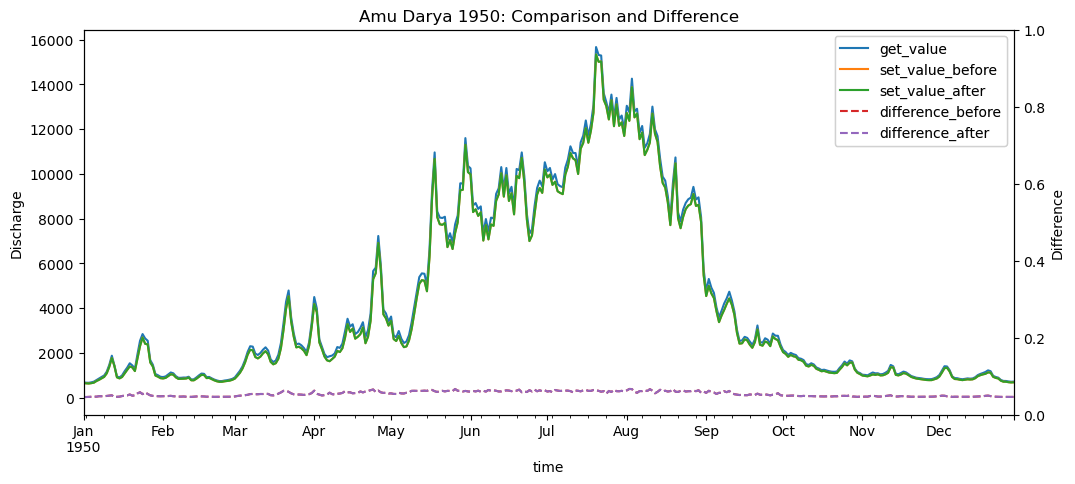

In [39]:
import matplotlib.pyplot as plt
import pandas as pd

# # Combine the two series for 1950
# combined = pd.concat([
#     stations_timeseries_getvalue.loc["1950", ["Chatly"]].rename(columns={"Chatly": "get_value"}),
#     stations_timeseries_setvalue.loc["1950", ["Chatly"]].rename(columns={"Chatly": "set_value"})
# ], axis=1)


# Create main plot for get_value and set_value
fig, ax = plt.subplots(figsize=(12, 5))
combined[["get_value", "set_value_before", "set_value_after"]].plot(ax=ax)
ax.set_ylabel("Discharge")
ax.set_title("Amu Darya 1950: Comparison and Difference")
ax.grid()

# Plot difference on secondary y-axis
ax2 = ax.twinx()
combined[["difference_before", "difference_after"]].plot(
    ax=ax, style="--", label=["difference_before", "difference_after"]
)
ax2.set_ylabel("Difference")

# Combine legends
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc="upper right")


plt.show()

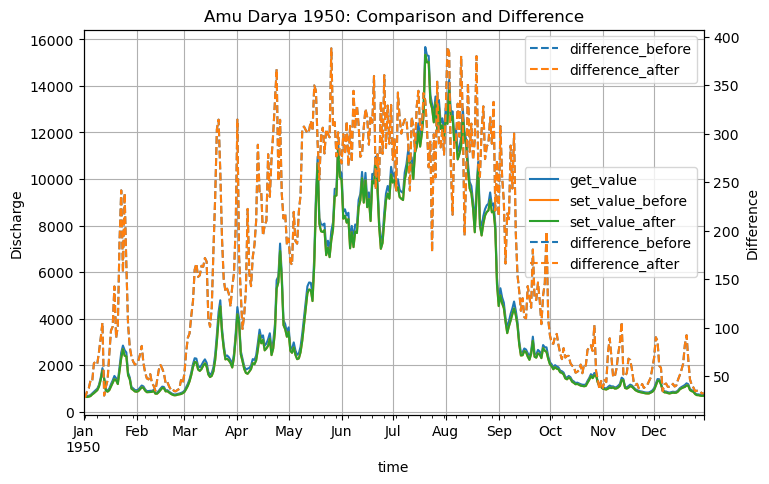

In [40]:
fig, ax = plt.subplots(figsize=(8, 5))
combined[["get_value", "set_value_before", "set_value_after"]].plot(ax=ax)
ax.set_ylabel("Discharge")
ax.set_title("Amu Darya 1950: Comparison and Difference")

ax.grid(True)
ax2 = ax.twinx()

combined[["difference_before", "difference_after"]].plot(
    ax=ax2, style="--"
)  # , label=["difference_before","difference_after"])
ax2.set_ylabel("Difference")

# Disable grid on second axis
ax2.grid(False)

# Combine legends
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc="center right")

plt.show()

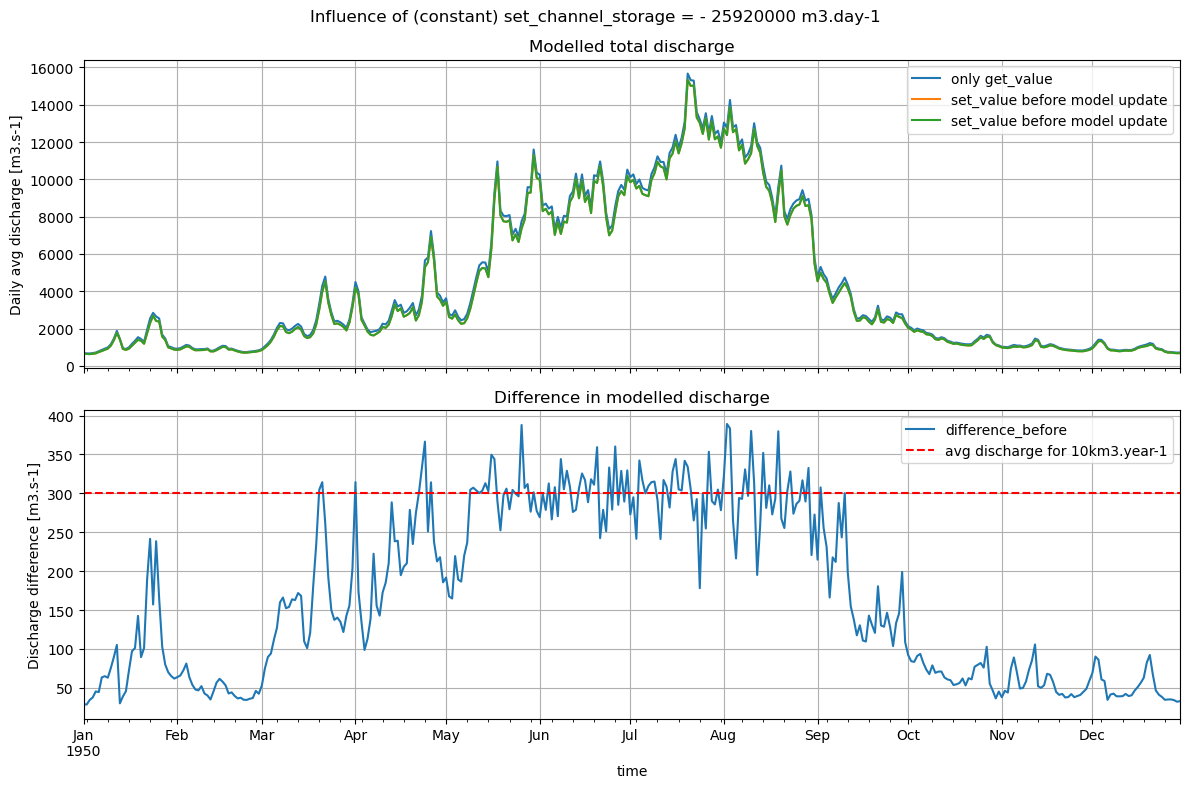

In [69]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

combined[["get_value", "set_value_before", "set_value_after"]].plot(ax=ax1)
ax1.set_ylabel("Daily avg discharge [m3.s-1]")
ax1.grid(True)
ax1.legend(["only get_value", "set_value before model update", "set_value before model update"])
ax1.set_title("Modelled total discharge")

combined[["difference_before"]].plot(ax=ax2, style="-", label=["difference_before"])
ax2.axhline(y=300, linestyle="--", color="red", label="avg discharge for 10km3.year-1")
ax2.set_ylabel("Discharge difference [m3.s-1]")
ax2.grid(True)
ax2.legend()
ax2.set_title("Difference in modelled discharge")

plt.suptitle(f"Influence of (constant) set_channel_storage = - {m3day} m3.day-1")
plt.tight_layout()
plt.show()

In [42]:
discharge_getvalue_plot = test_get_value.get_value_as_xarray("channel_storage")
discharge_setvalue_plot = test_set_value.get_value_as_xarray("channel_storage")

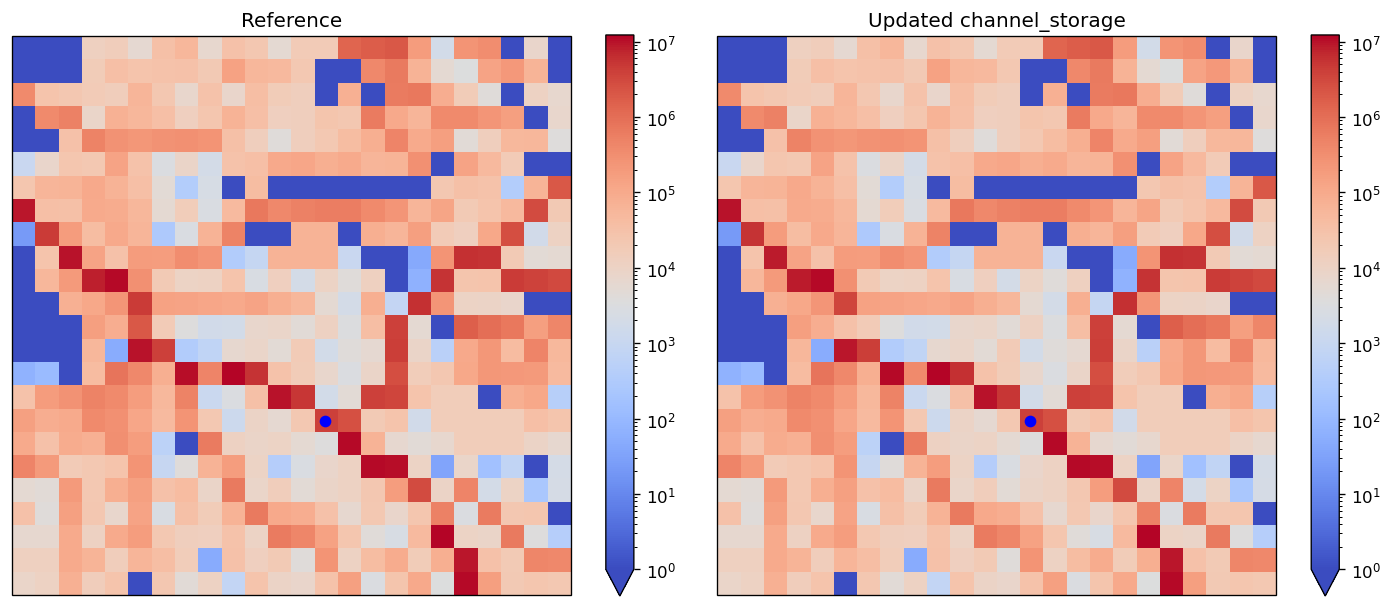

In [43]:
# -----------------------------
# Replace non-positive values
# -----------------------------
discharge_getvalue_plot_safe = discharge_getvalue_plot.where(discharge_getvalue_plot > 0, 1e-6)
discharge_setvalue_plot_safe = discharge_setvalue_plot.where(discharge_setvalue_plot > 0, 1e-6)

# Swap coordinates names
discharge_getvalue_plot_safe = discharge_getvalue_plot_safe.rename(
    {"latitude": "longitude", "longitude": "latitude"}
)

discharge_setvalue_plot_safe = discharge_setvalue_plot_safe.rename(
    {"latitude": "longitude", "longitude": "latitude"}
)

vmin_plot = 1
# -----------------------------
# Define zoom box (lon/lat)
# -----------------------------
lon_min, lon_max = 62.5, 64.5
lat_min, lat_max = 38.5, 40.5

# Ensure correct slicing even if coordinates are descending
lat0, lat1 = sorted([lat_min, lat_max])
lon0, lon1 = sorted([lon_min, lon_max])

get_value_subset = discharge_getvalue_plot_safe.sel(
    longitude=slice(lon0, lon1), latitude=slice(lat0, lat1)
)

set_value_subset = discharge_setvalue_plot_safe.sel(
    longitude=slice(lon0, lon1), latitude=slice(lat0, lat1)
)

# -----------------------------
# Set up figure
# -----------------------------
fig = plt.figure(figsize=(12, 5), dpi=120)
left_axes = fig.add_subplot(121, projection=ccrs.PlateCarree())
right_axes = fig.add_subplot(122, projection=ccrs.PlateCarree())

# -----------------------------
# Plot the subsets
# -----------------------------
get_value_subset.plot(
    ax=left_axes,
    x="longitude",
    y="latitude",
    cmap="coolwarm",
    norm=LogNorm(vmin=vmin_plot, vmax=get_value_subset.max()),
)

set_value_subset.plot(
    ax=right_axes,
    x="longitude",
    y="latitude",
    cmap="coolwarm",
    norm=LogNorm(vmin=vmin_plot, vmax=get_value_subset.max()),
)

# -----------------------------
# Decorations
# -----------------------------
left_axes.set_title("Reference")
right_axes.set_title("Updated channel_storage")

for ax in [left_axes, right_axes]:
    ax.add_feature(cfeature.OCEAN, zorder=2)
    ax.coastlines(zorder=3)

# -----------------------------
# Plot a point
# -----------------------------
point_lon, point_lat = 63.62, 39.122
for ax in [left_axes, right_axes]:
    ax.plot(
        point_lon, point_lat, color="blue", linewidth=2, marker="o", transform=ccrs.PlateCarree()
    )

plt.tight_layout()
plt.show()

In [44]:
reference.finalize()
test_get_value.finalize()
test_set_value.finalize()
test_set_value_before_update.finalize()